# Notebook 01 - Data Audit
## Compound Crisis Cascade: Kenya

**Purpose:**  
This notebook answers four questions:
1. What is the shape and structure of each dataset?
2. What is the temporal coverage - and where do datasets overlap in time?
3. What is the geographic coverage - and which counties appear across all datasets?
4. Where are the gaps, and how do we handle them transparently?

**Datasets:**
- `hdx_hapi_rainfall_ken.csv` - WFP rainfall and anomaly data
- `hdx_hapi_food_price_ken.csv` - WFP food market prices
- `hdx_hapi_conflict_event_ken.csv` - ACLED conflict events
- `hdx_hapi_food_security_ken.csv` - IPC food security phases
- `hdx_hapi_population_ken.csv` - UNFPA baseline population
- `hdx_hapi_poverty_rate_ken.csv` - Oxford OPHI poverty rates

**Source:** HDX Humanitarian API: https://data.humdata.org/dataset/hdx-hapi-ken  

## 0.0 Setup - Libraries and Configuration

In [23]:
# Standard library imports
import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

# Settings
warnings.filterwarnings('ignore')          # Suppress minor pandas warnings
pd.set_option('display.max_columns', 30)   # Show all columns in previews
pd.set_option('display.float_format', '{:.2f}'.format)  # Clean float display

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Project colour palette
# Consistent colours used across all notebooks
COLOURS = {
    'rainfall':    '#2166ac',   # Blue  - water/climate
    'food_price':   '#d6604d',   # Red   - price stress
    'conflict':     '#1a1a1a',   # Near-black - severity
    'food_security':'#f4a582',   # Salmon - hunger
    'poverty':      '#762a83',   # Purple - structural vulnerability
    'highlight':    '#fdae61',   # Amber  - callout
    'neutral':      '#878787',   # Grey   - background elements
}

print("Libraries loaded successfully.")
print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")

Libraries loaded successfully.
pandas  1.4.4
numpy   1.24.4


## 1. Load Datasets

In [2]:
# Build folder paths
RAW     = os.path.join('..', 'data', 'raw')
fig_dir = os.path.join('..', 'outputs', 'figures')
tbl_dir = os.path.join('..', 'outputs', 'tables')

# Create output folders if they do not exist
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tbl_dir, exist_ok=True)

In [4]:
# Load HDX HAPI datasets
# parse_dates converts reference period columns from string to datetime,
# which is essential for time-series analysis.
DATE_COLS = ['reference_period_start', 'reference_period_end']

def load_hapi(name):
    return pd.read_csv(
        os.path.join(RAW, f'hdx_hapi_{name}_ken.csv'),
        parse_dates=DATE_COLS
    )

In [5]:
# Load all datasets
# HDX HAPI datasets - four supporting datasets
hapi_names = [
    'conflict_event',
    'food_security',
    'population',
    'poverty_rate'
]
DATASETS = {name: load_hapi(name) for name in hapi_names}

# Primary datasets - new higher-resolution sources
DATASETS['rainfall']   = pd.read_csv(
    os.path.join(RAW, 'ken-rainfall-subnat-full.csv'),
    parse_dates=['date']
)
DATASETS['food_price'] = pd.read_csv(
    os.path.join(RAW, 'wfp_food_prices_ken.csv'),
    parse_dates=['date']
)

print("All datasets loaded successfully.")
print(f"Total datasets: {len(DATASETS)}")

All datasets loaded successfully.
Total datasets: 6


In [7]:
# view each dataset
for name, df in DATASETS.items():
    print(f"\n{' '}")
    print(f" {name.upper()}")
    print(f"{' '}")
    display(df.head(3))


 
 CONFLICT_EVENT
 


,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,reference_period_start,reference_period_end
0,Kenya,Turkana,Violence against civilians,Attack,1,3,NaN,Political violence,1577,2.98,35.36,1997-11-01,1997-01-17
1,Kenya,Mombasa,Violence against civilians,Attack,1,2,NaN,Political violence,1562,-4.00,39.60,1997-01-18,1997-01-24
2,Kenya,Nakuru,Violence against civilians,Attack,1,1,NaN,Political violence,1565,-0.46,36.10,1997-01-18,1997-01-24



 
 FOOD_SECURITY
 


,location_code,has_hrp,in_gho,provider_admin1_name,provider_admin2_name,admin1_code,admin1_name,admin2_code,admin2_name,admin_level,ipc_phase,ipc_type,population_in_phase,population_fraction_in_phase,reference_period_start,reference_period_end
0,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,all,current,16617000,1.00,2025-07-01,2025-09-30
1,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,3+,current,1760950,0.11,2025-07-01,2025-09-30
2,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,1,current,8426900,0.51,2025-07-01,2025-09-30



 
 POPULATION
 


...

,location_code,has_hrp,in_gho,provider_admin1_name,admin1_code,admin1_name,admin_level,mpi,headcount_ratio,intensity_of_deprivation,vulnerable_to_poverty,in_severe_poverty,reference_period_start,reference_period_end
0,KEN,False,True,NaN,NaN,NaN,0,0.24,50.10,47.25,26.97,19.62,2008-01-01,2009-12-31
1,KEN,False,True,NaN,NaN,NaN,0,0.16,35.39,45.75,32.06,11.95,2014-01-01,2014-12-31
2,KEN,False,True,NaN,NaN,NaN,0,0.10,23.03,44.73,26.86,6.84,2022-01-01,2022-12-31



 
 RAINFALL
 


,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,1981-01-01,1,51325,KE019,427.00,7.37,15.76,NaN,NaN,NaN,NaN,59.60,NaN,NaN,final
1,1981-01-11,1,51325,KE019,427.00,4.33,19.29,NaN,NaN,NaN,NaN,38.38,NaN,NaN,final
2,1981-01-21,1,51325,KE019,427.00,5.57,16.27,17.27,51.32,NaN,NaN,49.70,39.54,NaN,final



 
 FOOD_PRICE
 


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47


## 2. Dataset Shapes and Structure

We first confirm the row count, column count, and data types for each dataset.  
This helps catch truncated downloads and encoding issues.

In [8]:
# Summary table: rows, columns, date range
# rainfall and food_price use 'date'; others use 'reference_period_start'
def get_date_range(name, df):
    col = 'date' if name in ['rainfall', 'food_price'] else 'reference_period_start'
    return df[col].min().date(), df[col].max().date()

summary_rows = []
for name, df in DATASETS.items():
    d_start, d_end = get_date_range(name, df)
    summary_rows.append({
        'Dataset':    name,
        'Rows':       f"{len(df):,}",
        'Columns':    len(df.columns),
        'Date Start': d_start,
        'Date End':   d_end,
        'Null Cells': df.isnull().sum().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
print("Dataset Overview")
print(" ")
print(summary_df.to_string(index=False))

Dataset Overview
 
       Dataset    Rows  Columns Date Start   Date End  Null Cells
conflict_event  16,150       13 1997-01-18 2026-11-04        5122
 food_security   4,830       16 2019-07-01 2025-10-01       15848
    population   3,168       17 2019-01-01 2019-01-01        9702
  poverty_rate      73       14 2008-01-01 2022-01-01          39
      rainfall 132,273       15 1981-01-01 2026-05-01        2430
    food_price  26,648       16 2006-01-15 2026-03-15         272


In [9]:
# Inspect each dataset individually
# .info() shows column names, non-null counts, and dtypes
for name, df in DATASETS.items():
    print(f"\n{' '}")
    print(f" {name.upper()}")
    print(f"{' '}")
    df.info(verbose=True, show_counts=True)


 
 CONFLICT_EVENT
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16150 entries, 0 to 16149
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   COUNTRY                 16150 non-null  object        
 1   ADMIN1                  16150 non-null  object        
 2   EVENT_TYPE              16150 non-null  object        
 3   SUB_EVENT_TYPE          16150 non-null  object        
 4   EVENTS                  16150 non-null  int64         
 5   FATALITIES              16150 non-null  int64         
 6   POPULATION_EXPOSURE     11028 non-null  float64       
 7   DISORDER_TYPE           16150 non-null  object        
 8   ID                      16150 non-null  int64         
 9   CENTROID_LATITUDE       16150 non-null  float64       
 10  CENTROID_LONGITUDE      16150 non-null  float64       
 11  reference_period_start  16150 non-null  datetime64[ns]
 12  reference_period_end    1

## 3. Null Value Audit

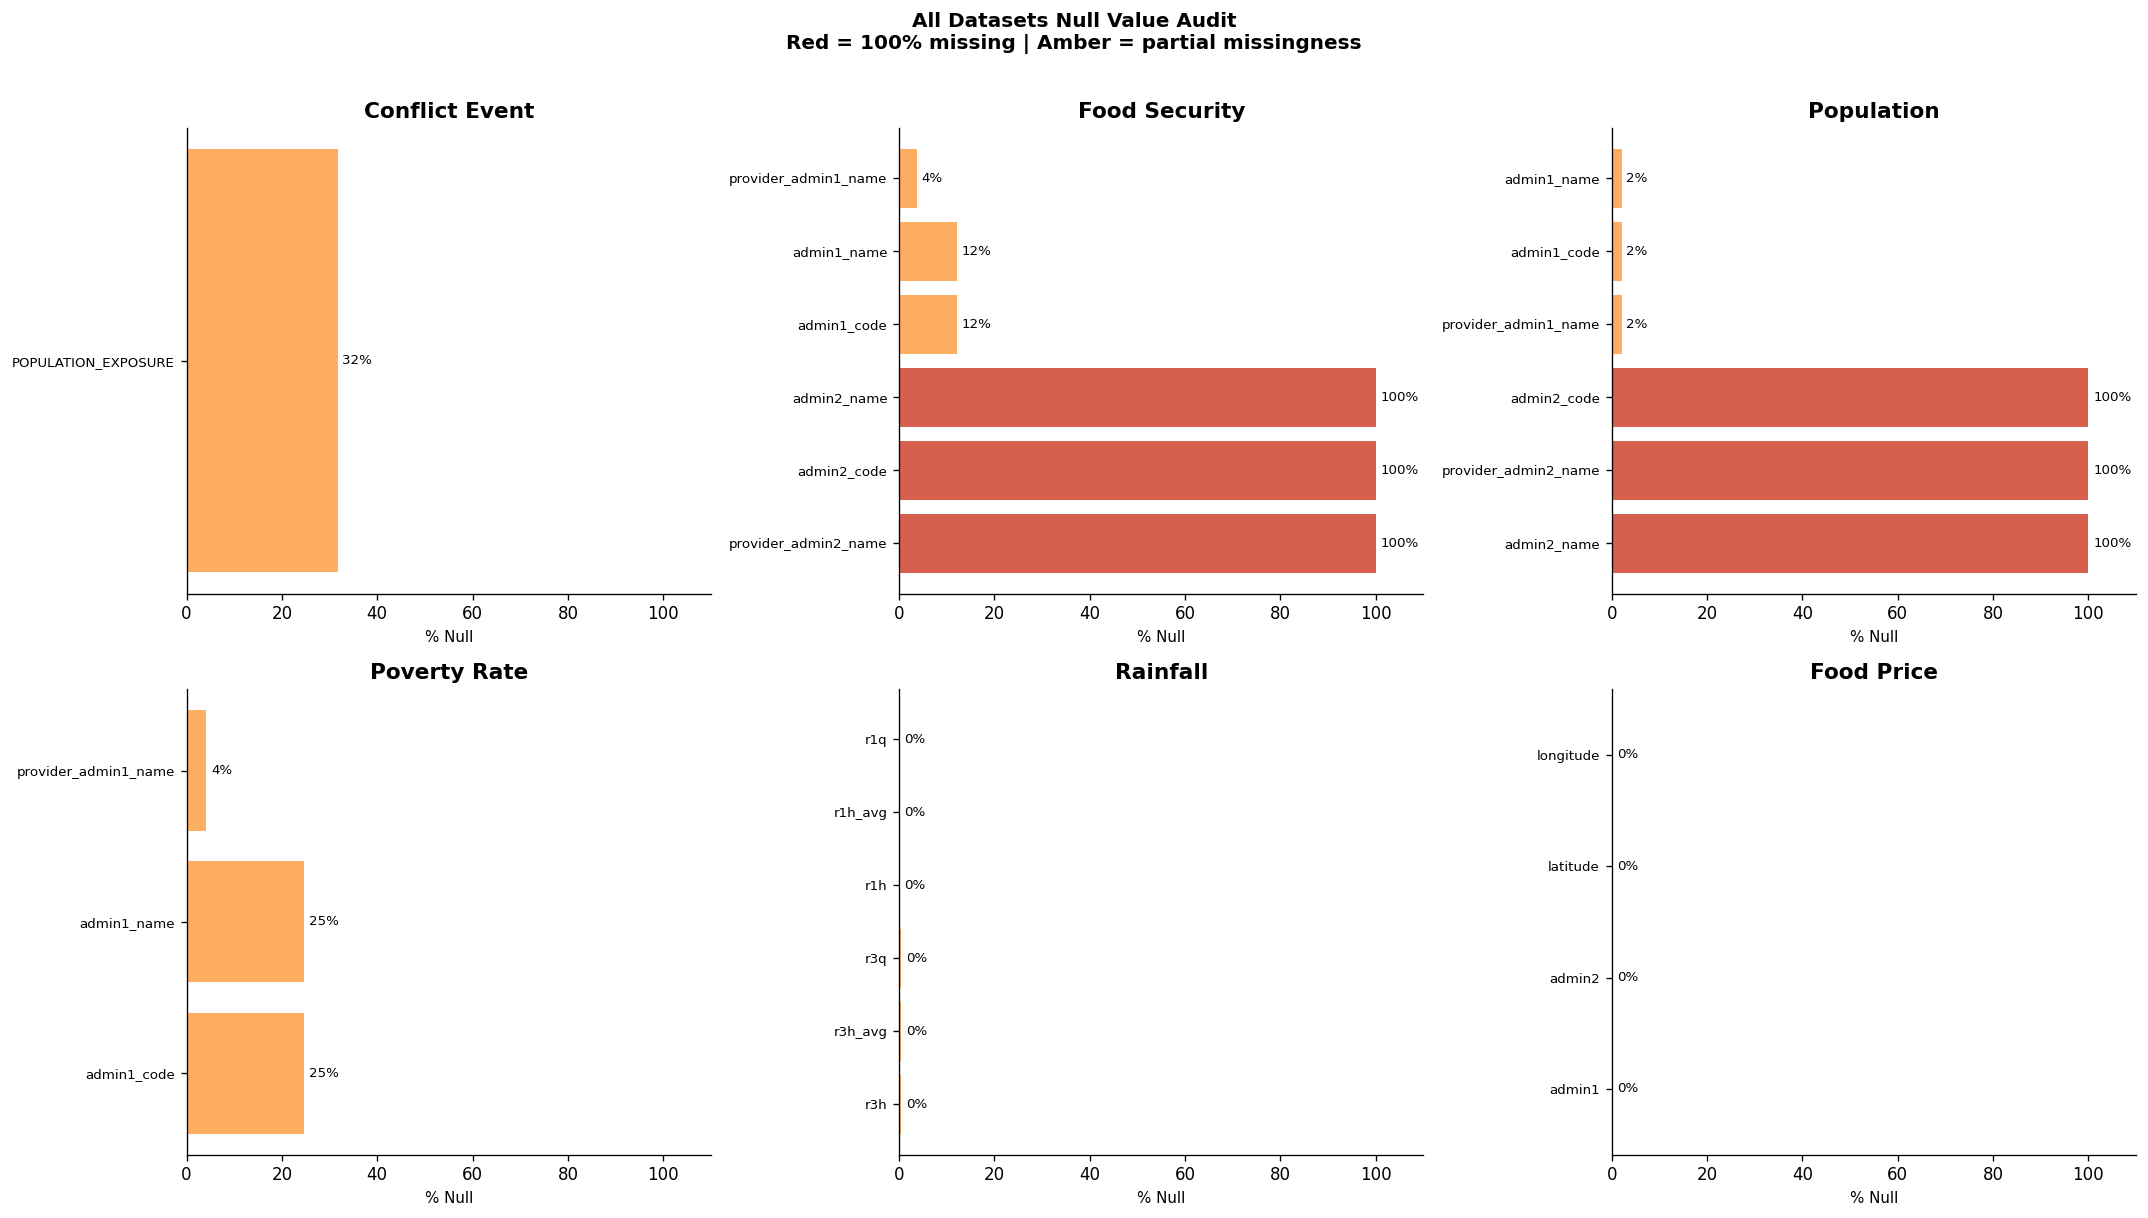

Saved: outputs/figures/01_null_value_audit.png


In [10]:
# Visualise missingness as a percentage per column per dataset
# Columns with 100% null are structurally missing - not a cleaning problem

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, df) in enumerate(DATASETS.items()):
    ax = axes[idx]

    # Calculate null percentage per column
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]  # Only show columns with any nulls

    if null_pct.empty:
        ax.text(0.5, 0.5, 'No nulls', ha='center', va='center',
                fontsize=14, color=COLOURS['neutral'])
        ax.set_title(name.replace('_', ' ').title(), fontweight='bold')
        ax.axis('off')
        continue

    # Red if 100% null (structural), amber if partial
    bar_colours = [
        COLOURS['food_price'] if v == 100 else COLOURS['highlight']
        for v in null_pct.values
    ]

    bars = ax.barh(null_pct.index, null_pct.values, color=bar_colours)
    ax.set_xlim(0, 110)
    ax.set_xlabel('% Null', fontsize=9)
    ax.set_title(name.replace('_', ' ').title(), fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

    for bar, val in zip(bars, null_pct.values):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%', va='center', fontsize=8)

plt.suptitle(
    'All Datasets Null Value Audit\n'
    'Red = 100% missing | Amber = partial missingness',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_null_value_audit.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_null_value_audit.png")

## 4. Temporal Coverage
We need to know how far back each dataset goes and where they overlap.  
The overlap window determines the time period we can actually analyse.

In [11]:
# Temporal summary table
print("Temporal Coverage Summary")
print(" ")
print(f"{'Dataset':<18} {'Start':<14} {'End':<14} {'Notes'}")
print("-" * 70)

notes = {
    'rainfall':       'Dekadal (10-day) - 45 years | PRIMARY',
    'food_price':     'Monthly - 20 years | PRIMARY',
    'conflict_event': 'Sub-weekly - county level, 2000-2026',
    'food_security':  'Snapshot-based IPC phases',
    'population':     'Static 2019 census - use as scalar',
    'poverty_rate':   'Static survey - use for stratification',
}

for name, df in DATASETS.items():
    col   = 'date' if name in ['rainfall','food_price'] else 'reference_period_start'
    start = df[col].min().date()
    end   = df[col].max().date()
    print(f"{name:<18} {str(start):<14} {str(end):<14} {notes.get(name,'')}")

print()
print("Analysis window: 2006-01-15 to 2026-03-15 (20 years)")
print("Binding constraint: food price data starts January 2006.")

Temporal Coverage Summary
 
Dataset            Start          End            Notes
----------------------------------------------------------------------
conflict_event     1997-01-18     2026-11-04     Sub-weekly - county level, 2000-2026
food_security      2019-07-01     2025-10-01     Snapshot-based IPC phases
population         2019-01-01     2019-01-01     Static 2019 census - use as scalar
poverty_rate       2008-01-01     2022-01-01     Static survey - use for stratification
rainfall           1981-01-01     2026-05-01     Dekadal (10-day) - 45 years | PRIMARY
food_price         2006-01-15     2026-03-15     Monthly - 20 years | PRIMARY

Analysis window: 2006-01-15 to 2026-03-15 (20 years)
Binding constraint: food price data starts January 2006.


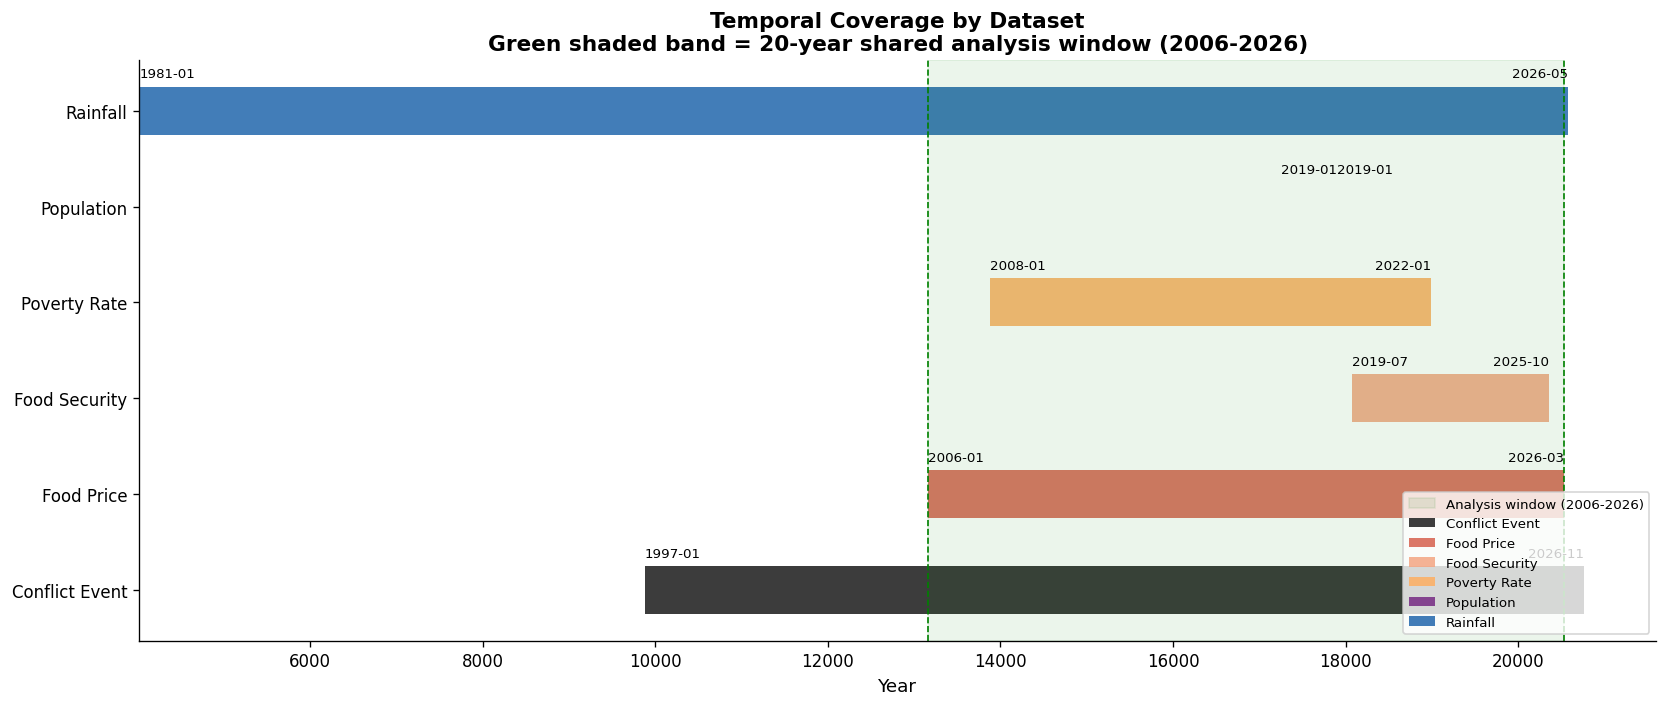

Saved: outputs/figures/01_temporal_coverage.png


In [12]:
# Temporal coverage timeline chart
fig, ax = plt.subplots(figsize=(14, 6))

dataset_order = [
    'conflict_event', 'food_price', 'food_security',
    'poverty_rate', 'population', 'rainfall'
]

colour_map = {
    'rainfall':       COLOURS['rainfall'],
    'food_price':     COLOURS['food_price'],
    'conflict_event': COLOURS['conflict'],
    'food_security':  COLOURS['food_security'],
    'population':     COLOURS['poverty'],
    'poverty_rate':   COLOURS['highlight'],
}

for idx, name in enumerate(dataset_order):
    df    = DATASETS[name]
    col   = 'date' if name in ['rainfall','food_price'] else 'reference_period_start'
    start = df[col].min()
    end   = df[col].max()

    ax.barh(
        y=idx,
        width=(end - start).days,
        left=start,
        height=0.5,
        color=colour_map[name],
        alpha=0.85,
        label=name.replace('_', ' ').title()
    )
    ax.text(start, idx + 0.32, f"{start.strftime('%Y-%m')}", fontsize=8, va='bottom')
    ax.text(end,   idx + 0.32, f"{end.strftime('%Y-%m')}",   fontsize=8, va='bottom', ha='right')

# Mark the analysis overlap window
overlap_start = pd.Timestamp('2006-01-15')
overlap_end   = pd.Timestamp('2026-03-15')
ax.axvspan(
    overlap_start, overlap_end,
    alpha=0.08, color='green', label='Analysis window (2006-2026)'
)
ax.axvline(overlap_start, color='green', linestyle='--', linewidth=1)
ax.axvline(overlap_end,   color='green', linestyle='--', linewidth=1)

ax.set_yticks(range(len(dataset_order)))
ax.set_yticklabels([d.replace('_', ' ').title() for d in dataset_order], fontsize=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_title(
    'Temporal Coverage by Dataset\n'
    'Green shaded band = 20-year shared analysis window (2006-2026)',
    fontweight='bold'
)
ax.legend(loc='lower right', fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_temporal_coverage.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_temporal_coverage.png")

## 5. Geographic Coverage

Kenya has 47 counties. Not every dataset covers all 47.  
We need to know the county overlap to define our analysis scope.

In [13]:
# PCODE to county name lookup
# Rainfall uses Kenya P-codes; food price uses plain county names
# This lookup resolves the join key mismatch
PCODE_COUNTY = {
    'KE001': 'Mombasa',         'KE002': 'Kwale',           'KE003': 'Kilifi',
    'KE004': 'Tana River',      'KE005': 'Lamu',            'KE006': 'Taita Taveta',
    'KE007': 'Garissa',         'KE008': 'Wajir',           'KE009': 'Mandera',
    'KE010': 'Marsabit',        'KE011': 'Isiolo',          'KE012': 'Meru',
    'KE013': 'Tharaka-Nithi',   'KE014': 'Embu',            'KE015': 'Kitui',
    'KE016': 'Machakos',        'KE017': 'Makueni',         'KE018': 'Nyandarua',
    'KE019': 'Nyeri',           'KE020': 'Kirinyaga',       'KE021': "Murang'a",
    'KE022': 'Kiambu',          'KE023': 'Turkana',         'KE024': 'West Pokot',
    'KE025': 'Samburu',         'KE026': 'Trans Nzoia',     'KE027': 'Uasin Gishu',
    'KE028': 'Elgeyo-Marakwet', 'KE029': 'Nandi',           'KE030': 'Baringo',
    'KE031': 'Laikipia',        'KE032': 'Nakuru',          'KE033': 'Narok',
    'KE034': 'Kajiado',         'KE035': 'Kericho',         'KE036': 'Bomet',
    'KE037': 'Kakamega',        'KE038': 'Vihiga',          'KE039': 'Bungoma',
    'KE040': 'Busia',           'KE041': 'Siaya',           'KE042': 'Kisumu',
    'KE043': 'Homa Bay',        'KE044': 'Migori',          'KE045': 'Kisii',
    'KE046': 'Nyamira',         'KE047': 'Nairobi'
}

# Map rainfall admin2 PCODEs to county names
# Admin2 PCODE format: KE023045 - parent county = first 5 chars = KE023 = Turkana
adm2 = DATASETS['rainfall'][DATASETS['rainfall']['adm_level'] == 2].copy()
adm2['parent_pcode'] = adm2['PCODE'].str[:5]
adm2['county']       = adm2['parent_pcode'].map(PCODE_COUNTY)

print(f"PCODE lookup loaded: {len(PCODE_COUNTY)} counties")
print(f"Admin2 rows mapped: {adm2['county'].notna().sum():,} of {len(adm2):,}")

PCODE lookup loaded: 47 counties
Admin2 rows mapped: 119,209 of 119,209


In [17]:
# County coverage per dataset 

# County coverage per dataset
rain_counties  = set(adm2['county'].dropna().unique())
price_counties = set(DATASETS['food_price']['admin2'].dropna().unique())
fs_counties    = set(DATASETS['food_security']['admin1_name'].dropna().unique())
pov_counties   = set(DATASETS['poverty_rate']['admin1_name'].dropna().unique())
pop_counties   = set(DATASETS['population']['admin1_name'].dropna().unique())
conf_counties  = set(DATASETS['conflict_event']['ADMIN1'].dropna().unique())

coverage = {
    'Rainfall (new)':      rain_counties,
    'Food Price (new)':    price_counties,
    'Food Security (IPC)': fs_counties,
    'Poverty Rate':        pov_counties,
    'Population':          pop_counties,
    'Conflict':            conf_counties,
}

In [15]:
# Primary analysis counties - intersection of rainfall and food price
primary_overlap = sorted(rain_counties.intersection(price_counties))

print(f"Rainfall counties:         {len(rain_counties)}")
print(f"Food price counties:       {len(price_counties)}")
print()
print(f"PRIMARY ANALYSIS (Rainfall x Food Price): {len(primary_overlap)} counties")
print(primary_overlap)

Rainfall counties:         47
Food price counties:       27

PRIMARY ANALYSIS (Rainfall x Food Price): 23 counties
['Baringo', 'Garissa', 'Isiolo', 'Kajiado', 'Kilifi', 'Kisumu', 'Kitui', 'Kwale', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Mombasa', 'Nairobi', 'Nakuru', 'Nyeri', 'Samburu', 'Taita Taveta', 'Tana River', 'Turkana', 'Uasin Gishu', 'Wajir', 'West Pokot']


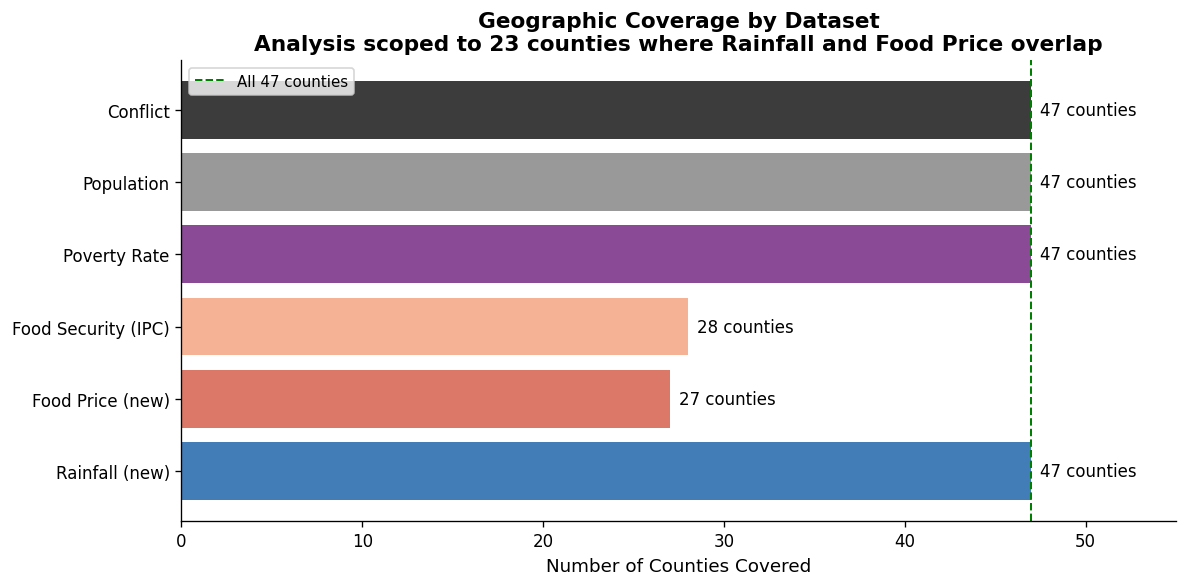

Saved: outputs/figures/01_geographic_coverage.png


In [18]:
# County coverage bar chart
dataset_names  = list(coverage.keys())
dataset_counts = [len(v) for v in coverage.values()]
bar_colours    = [
    COLOURS['rainfall'], COLOURS['food_price'], COLOURS['food_security'],
    COLOURS['poverty'],  COLOURS['neutral'],    COLOURS['conflict']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(dataset_names, dataset_counts, color=bar_colours, alpha=0.85)

# Add 47-county reference line
ax.axvline(47, color='green', linestyle='--', linewidth=1.2, label='All 47 counties')

# Annotate count on each bar
for bar, count in zip(bars, dataset_counts):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{count} counties',
        va='center', fontsize=10
    )

ax.set_xlim(0, 55)
ax.set_xlabel('Number of Counties Covered', fontsize=11)
ax.set_title(
    'Geographic Coverage by Dataset\n'
    'Analysis scoped to 23 counties where Rainfall and Food Price overlap',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_geographic_coverage.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_geographic_coverage.png")

## 6. Poverty Stratification - Identifying Vulnerable Counties

The poverty dataset is a survey (static), not a time series.  
We use it to classify all 47 counties into vulnerability tiers.  
These tiers will stratify all subsequent analysis:  
the cascade effect should be strongest in the highest-vulnerability counties.

In [24]:
# Classify counties into vulnerability tiers using MPI
# MPI = Multidimensional Poverty Index (0 to 1; higher = more deprived)
# Source: Oxford Poverty & Human Development Initiative (OPHI)

# Use most recent MPI value per county (some counties have multiple survey years)
poverty_latest = (
    DATASETS['poverty_rate']
    .sort_values('reference_period_start', ascending=False)
    .dropna(subset=['admin1_name', 'mpi'])
    .drop_duplicates(subset='admin1_name', keep='first')
    [['admin1_name', 'mpi', 'headcount_ratio', 'in_severe_poverty']]
    .copy()
)

# Define vulnerability tiers based on Kenya's national MPI distribution
def assign_tier(mpi):
    if mpi >= 0.30:
        return 'High'      # Chronically deprived - ASAL counties
    elif mpi >= 0.15:
        return 'Medium'    # Moderate deprivation
    else:
        return 'Low'       # Relatively better off

poverty_latest['vulnerability_tier'] = poverty_latest['mpi'].apply(assign_tier)

# Summary
tier_counts = poverty_latest['vulnerability_tier'].value_counts()
print("Vulnerability Tier Distribution")
print(" ")
for tier in ['High', 'Medium', 'Low']:
    n = tier_counts.get(tier, 0)
    print(f"{tier:<10} {n:>2} counties")

print()
print("High vulnerability counties (MPI >= 0.30):")
high_vuln = poverty_latest[poverty_latest['vulnerability_tier']=='High']
print(high_vuln[['admin1_name','mpi','headcount_ratio']]
      .sort_values('mpi', ascending=False)
      .to_string(index=False))

# Store as constant for use in all subsequent notebooks
HIGH_VULN = high_vuln['admin1_name'].tolist()

Vulnerability Tier Distribution
 
High        7 counties
Medium      8 counties
Low        32 counties

High vulnerability counties (MPI >= 0.30):
admin1_name  mpi  headcount_ratio
    Turkana 0.50            79.55
    Mandera 0.46            81.34
    Samburu 0.42            70.16
      Wajir 0.40            73.11
 Tana River 0.38            67.29
 West Pokot 0.35            65.79
   Marsabit 0.35            63.56


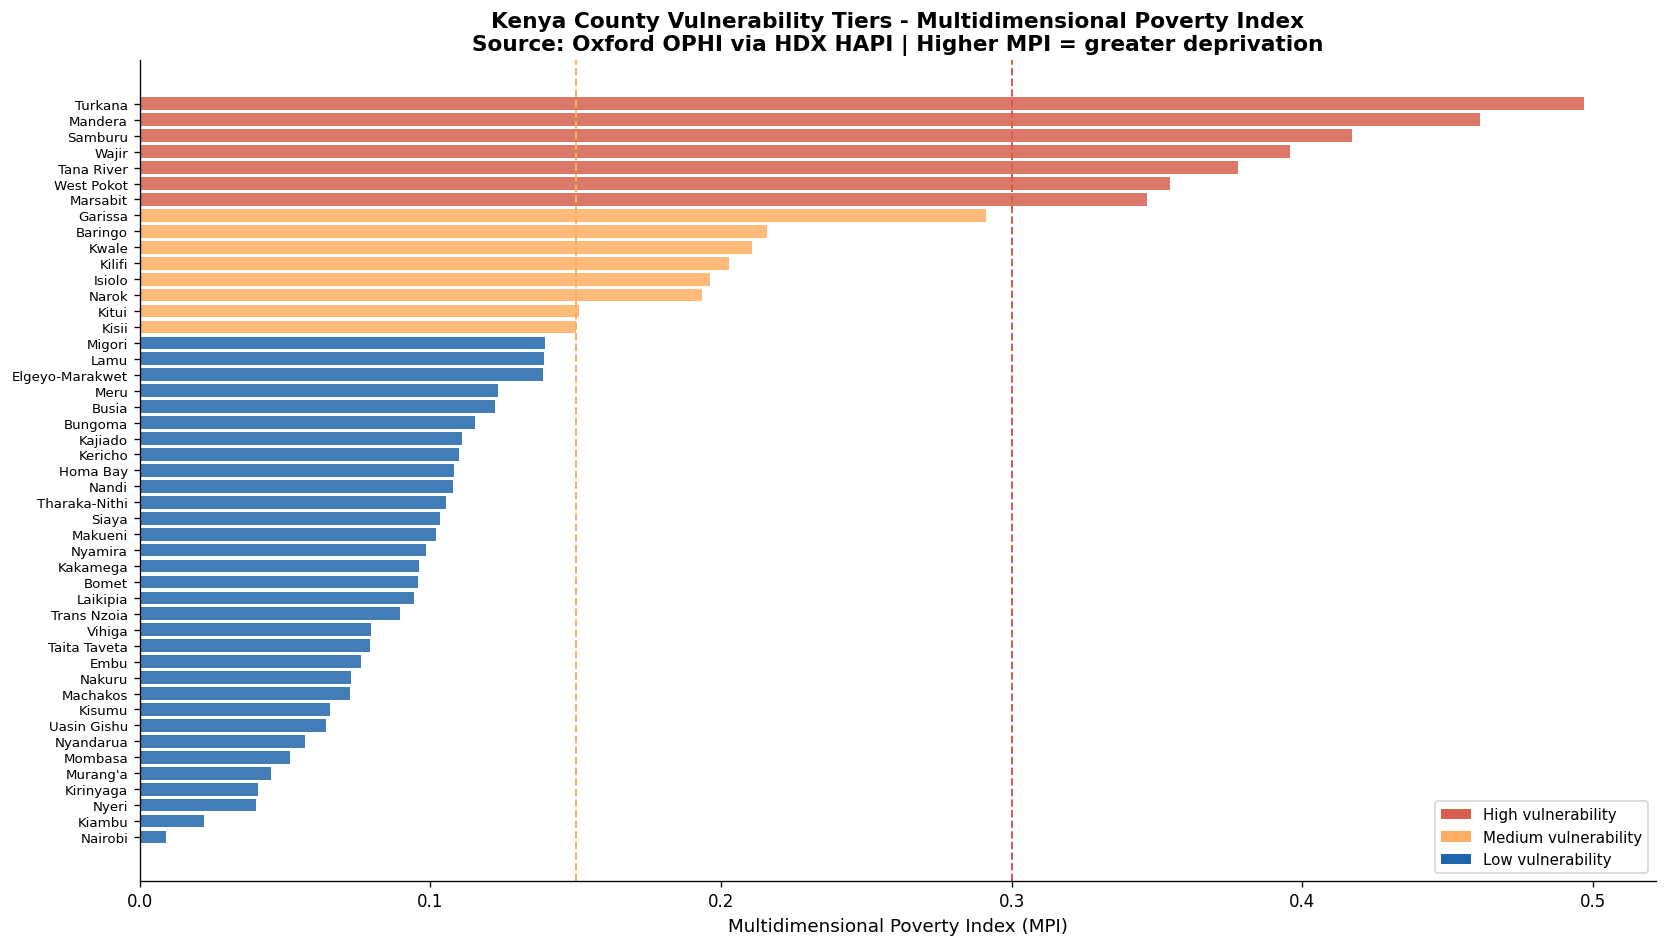

Saved: outputs/figures/01_poverty_vulnerability_tiers.png


In [25]:
# MPI distribution chart
poverty_plot = poverty_latest.sort_values('mpi', ascending=True).copy()

tier_colour_map = {
    'High':   COLOURS['food_price'],
    'Medium': COLOURS['highlight'],
    'Low':    COLOURS['rainfall'],
}
bar_cols = poverty_plot['vulnerability_tier'].map(tier_colour_map)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(
    poverty_plot['admin1_name'],
    poverty_plot['mpi'],
    color=bar_cols,
    alpha=0.85
)

# Tier threshold lines
ax.axvline(0.30, color=COLOURS['food_price'], linestyle='--',
           linewidth=1.2, label='High threshold (MPI = 0.30)')
ax.axvline(0.15, color=COLOURS['highlight'],  linestyle='--',
           linewidth=1.2, label='Medium threshold (MPI = 0.15)')

legend_elements = [
    Patch(facecolor=COLOURS['food_price'], label='High vulnerability'),
    Patch(facecolor=COLOURS['highlight'],  label='Medium vulnerability'),
    Patch(facecolor=COLOURS['rainfall'],   label='Low vulnerability'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

ax.set_xlabel('Multidimensional Poverty Index (MPI)', fontsize=11)
ax.set_title(
    'Kenya County Vulnerability Tiers - Multidimensional Poverty Index\n'
    'Source: Oxford OPHI via HDX HAPI | Higher MPI = greater deprivation',
    fontweight='bold'
)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_poverty_vulnerability_tiers.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_poverty_vulnerability_tiers.png")

## 7. Rainfall Anomaly Overview

Before we use `rainfall_anomaly_pct` as our primary climate shock indicator,  
we confirm it is plausible - the values should centre around 100%  
(100% = exactly average), with deficits below and surpluses above.

In [26]:
# Rainfall anomaly distribution
# Filter to admin2 level within the analysis window
adm2_analysis = adm2[
    (adm2['county'].isin(primary_overlap)) &
    (adm2['date'] >= overlap_start)
].copy()

print("Rainfall Anomaly Summary (rfq, admin2, analysis counties)")
print(" ")
stats = adm2_analysis['rfq'].describe()
print(stats.round(1))

print()
deficit_pct = (adm2_analysis['rfq'] < 80).mean() * 100
surplus_pct = (adm2_analysis['rfq'] > 120).mean() * 100
print(f"Dekad-county with deficit (< 80%):  {deficit_pct:.1f}%")
print(f"Dekad-county with surplus (> 120%): {surplus_pct:.1f}%")

Rainfall Anomaly Summary (rfq, admin2, analysis counties)
 
count   21930.00
mean      105.90
std        64.90
min        12.90
25%        67.40
50%        93.10
75%       120.90
max      1086.60
Name: rfq, dtype: float64

Dekad-county with deficit (< 80%):  36.5%
Dekad-county with surplus (> 120%): 25.3%


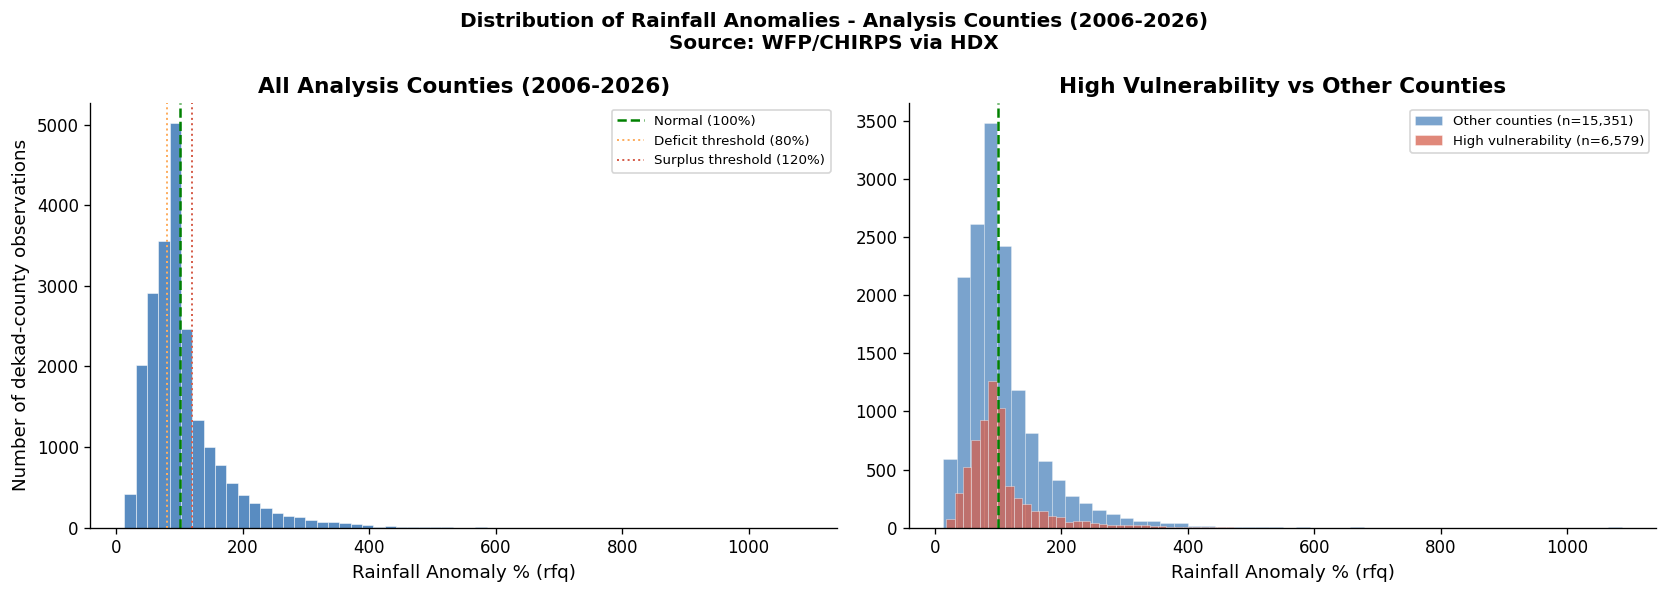

Saved: outputs/figures/01_rainfall_anomaly_distribution.png


In [28]:
# Rainfall anomaly histogram
hv_rfq    = adm2_analysis[adm2_analysis['county'].isin(HIGH_VULN)]['rfq']
other_rfq = adm2_analysis[~adm2_analysis['county'].isin(HIGH_VULN)]['rfq']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall distribution
ax = axes[0]
ax.hist(
    adm2_analysis['rfq'],
    bins=60,
    color=COLOURS['rainfall'],
    alpha=0.75,
    edgecolor='white',
    linewidth=0.4
)
ax.axvline(100, color='green',               linestyle='--', linewidth=1.5, label='Normal (100%)')
ax.axvline(80,  color=COLOURS['highlight'],  linestyle=':',  linewidth=1.2, label='Deficit threshold (80%)')
ax.axvline(120, color=COLOURS['food_price'], linestyle=':',  linewidth=1.2, label='Surplus threshold (120%)')
ax.set_xlabel('Rainfall Anomaly % (rfq)', fontsize=11)
ax.set_ylabel('Number of dekad-county observations', fontsize=11)
ax.set_title('All Analysis Counties (2006-2026)', fontweight='bold')
ax.legend(fontsize=8)

# Right: high vulnerability vs other counties
ax2 = axes[1]
ax2.hist(
    other_rfq, bins=50, color=COLOURS['rainfall'],  alpha=0.6,
    edgecolor='white', linewidth=0.3,
    label=f'Other counties (n={len(other_rfq):,})'
)
ax2.hist(
    hv_rfq, bins=50, color=COLOURS['food_price'], alpha=0.75,
    edgecolor='white', linewidth=0.3,
    label=f'High vulnerability (n={len(hv_rfq):,})'
)
ax2.axvline(100, color='green', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Rainfall Anomaly % (rfq)', fontsize=11)
ax2.set_title('High Vulnerability vs Other Counties', fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle(
    'Distribution of Rainfall Anomalies - Analysis Counties (2006-2026)\n'
    'Source: WFP/CHIRPS via HDX',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, '01_rainfall_anomaly_distribution.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("Saved: outputs/figures/01_rainfall_anomaly_distribution.png")

## 8. Save Reference Tables

Every subsequent notebook imports these files rather than re-running this logic.  
This ensures county lists and tier assignments stay consistent across all notebooks.

In [29]:
# Save analysis county list
county_df = pd.DataFrame({
    'county':       primary_overlap,
    'is_high_vuln': [c in HIGH_VULN for c in primary_overlap],
    'pcode':        [
        next((k for k, v in PCODE_COUNTY.items() if v == c), None)
        for c in primary_overlap
    ]
})

county_path = os.path.join(tbl_dir, '01_analysis_counties.csv')
county_df.to_csv(county_path, index=False)
print(f"Saved: {county_path}")
print(f"Analysis counties: {len(county_df)}")
print()
print(county_df.to_string(index=False))

Saved: ..\outputs\tables\01_analysis_counties.csv
Analysis counties: 23

      county  is_high_vuln pcode
     Baringo         False KE030
     Garissa         False KE007
      Isiolo         False KE011
     Kajiado         False KE034
      Kilifi         False KE003
      Kisumu         False KE042
       Kitui         False KE015
       Kwale         False KE002
    Machakos         False KE016
     Makueni         False KE017
     Mandera          True KE009
    Marsabit          True KE010
     Mombasa         False KE001
     Nairobi         False KE047
      Nakuru         False KE032
       Nyeri         False KE019
     Samburu          True KE025
Taita Taveta         False KE006
  Tana River          True KE004
     Turkana          True KE023
 Uasin Gishu         False KE027
       Wajir          True KE008
  West Pokot          True KE024


In [30]:
# Save vulnerability tier lookup
tier_path = os.path.join(tbl_dir, '01_vulnerability_tiers.csv')
poverty_latest.to_csv(tier_path, index=False)
print(f"Saved: {tier_path}")
print(f"Counties with tier assigned: {len(poverty_latest)}")

Saved: ..\outputs\tables\01_vulnerability_tiers.csv
Counties with tier assigned: 47
